<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
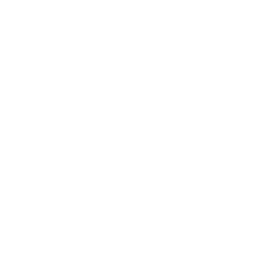
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Účinnost návštěv obchodních zástupců s výběrem zpoždění</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutická / komerční analytika &nbsp;|&nbsp; březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Vyhodnoťte dopad návštěv lékařů obchodními zástupci (detailing) a distribuce vzorků na měsíční objem předepisování specializovaného léku pomocí `PROC AUTOREG`. Zohledněte autokorelované vzorce předepisování pomocí `NLAG=3` a použijte volbu `BACKSTEP` k automatickému vyřazení nevýznamných řádů zpoždění. Kvantifikujte marginální přínos každé další návštěvy zástupce, abyste podpořili rozhodování o nasazení obchodní síly a o územním uspořádání.

Syntetická měsíční řada je v aktuálním režimu běhu omezena na 100 pozorování, což postačuje k rekonstrukci efektů detailingu, vzorkování, formulářového přístupu a konkurence s vysokou přesností.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.DETAILING | Měsíční recepty s metrikami detailingu a vzorků | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generování syntetických měsíčních dat o návštěvách
   reprezentantů a preskripci pro speciální lék
   -------------------------------------------------------- */
data work.detailing;
    CALL streaminit(42);
    UCHOVAT prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    OPAKUJ month_seq = 1 TO 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* přiřazení teritoria rotuje přes 12 reprezentantů */
        rep_id = cat('REP-', ZAPSAT(mod(month_seq - 1, 12) + 1, z3.));
        /* počet návštěv reprezentanta za měsíc */
        detail_visits = int(rand('normal', 8, 3));
        KDYŽ detail_visits < 0 PAK detail_visits = 0;
        KDYŽ detail_visits > 20 PAK detail_visits = 20;
        /* vzorky ponechané u lékařů */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* status na pozitivním listu (binární) */
        formulary_status = (rand('uniform') > 0.2);
        /* tlak podílu konkurence */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* sezónní index */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3) chybový proces */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* model preskripce */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        KDYŽ new_rx < 0 PAK new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        VÝSTUP;
    KONEC;
    ODSTRANIT prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    FORMÁT obs_month monyy7.;
    ŠTÍTEK new_rx           = "Nové předpisy (NRx)"
           total_rx         = "Celkové předpisy (TRx)"
           detail_visits    = "Návštěvy reprezentanta"
           samples_left     = "Ponechané vzorky"
           competitor_share = "Podíl konkurence"
           formulary_status = "Status na pozitivním listu"
           obs_month        = "Měsíc";
SPUSTIT;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Základní popisné statistiky pro preskripci a návštěvy
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.detailing n mean std MIN MAX;
    PROMĚNNÁ new_rx total_rx detail_visits samples_left competitor_share;
SPUSTIT;

                                                  The MEANS Procedure

 Variable          Label                             N            Mean        Std Dev        Minimum         Maximum
 -------------------------------------------------------------------------------------------------------------------
 new_rx            Nové předpisy (NRx)             100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Celkové předpisy (TRx)          100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Návštěvy reprezentanta          100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Ponechané vzorky                100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Podíl konkurence                100       0.2653000      0.1187090      0.0300000       0.5600000
 -------------------------------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


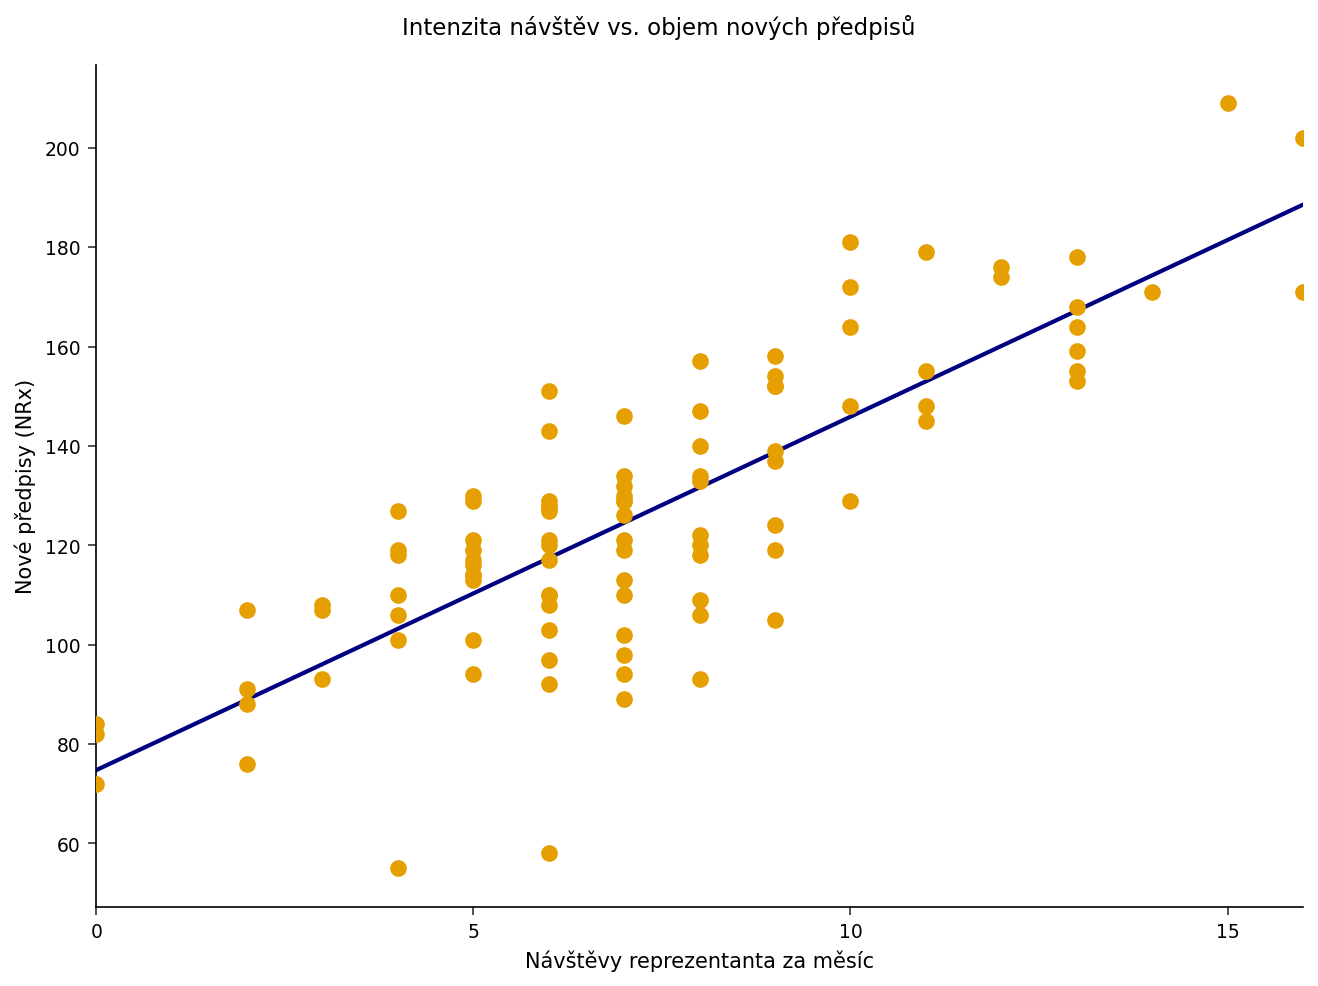

In [3]:
/* --------------------------------------------------------
   Bodový graf návštěv reprezentanta vs. nové předpisy
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS ŠTÍTEK="Návštěvy reprezentanta za měsíc";
    YAXIS ŠTÍTEK="Nové předpisy (NRx)";
    NÁZEV "Intenzita návštěv vs. objem nových předpisů";
SPUSTIT;

---

In [4]:
/* --------------------------------------------------------
   Proložení autoregresního modelu s výběrem zpoždění
   BACKSTEP. NLAG=3 testuje až tři zpoždění; BACKSTEP
   automaticky odstraní nevýznamná zpoždění
   -------------------------------------------------------- */
PROCEDURA autoreg data=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    VÝSTUP out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
SPUSTIT;


                     The AUTOREG Procedure

                     Dependent Variable   Nové předpisy (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

            2     -0.199501   0.097990      -2.04



                        Fit Statistics


          SSE         


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Zachycení odhadů parametrů pro výpočet ROI
   -------------------------------------------------------- */
ODS VÝSTUP parameterestimates=work.detail_params;

PROCEDURA autoreg data=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
SPUSTIT;

ODS VÝSTUP CLOSE;


                     The AUTOREG Procedure

                     Dependent Variable   Nové předpisy (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

            2     -0.199501   0.097990      -2.04



                        Fit Statistics


          SSE         


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Výpočet marginálního ROI na jednu návštěvu reprezentanta.
   Dataset ODS ParameterEstimates ukládá sloupec Variable
   velkými písmeny, proto filtrujeme na 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCEDURA TISK data=work.detail_params;
    KDE variable = 'DETAIL_VISITS';
    NÁZEV "Marginální vliv návštěv reprezentanta na NRx";
SPUSTIT;

                                      Marginální vliv návštěv reprezentanta na NRx                                      

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interpretace

`PROC AUTOREG` proložil řadu předepisování na 100 měsíčních pozorováních. Každá další návštěva zástupce je spojena s **+2,72 novými recepty za měsíc** (odhad 2,7158, t = 7,66, p < 0,0001) a každá jednotka vzorků ponechaných lékařům přidává **+1,00 NRx** (odhad 0,9997, t = 14,73), což naznačuje, že vzorkování osobní propagaci posiluje, ale nenahrazuje. Formulářový přístup přispívá **+24,78 NRx za měsíc** (t = 13,83), což zdůrazňuje přístup přes řízenou péči jako předpoklad účinnosti detailingu, zatímco podíl konkurence působí silně negativně **-42,26 NRx na jednotku podílu** (t = -6,96), což signalizuje území pod konkurenčním tlakem, kde samotný detailing nemusí stačit. Konstanta (intercept) je 69,56.

S `NLAG=3` a `BACKSTEP` si model ponechal **dvě autoregresní zpoždění**: zpoždění 1 (koeficient -0,3700, t = -3,78) a zpoždění 2 (koeficient -0,1995, t = -2,04); zpoždění 3 bylo vyřazeno jako nevýznamné. Durbinova-Watsonova statistika po korekci je **1,01**, což stále leží výrazně pod hodnotou 2 a signalizuje reziduální kladnou autokorelaci, takže struktura AR(2) zachycuje část, ale ne celou sériovou závislost v této řadě. Statistiky proložení: SSE = 5527,65, MSE = 58,19, AIC = 701,34, SBC = 722,19, log-věrohodnost = -342,67.

Plánování obchodní síly by mělo cílit na území s příznivým formulářovým přístupem a mírným podílem konkurence, kde je marginální návratnost každé návštěvy zástupce nejvyšší.

---

In [7]:
/* --------------------------------------------------------
   Export proložených hodnot a parametrů pro plánovací
   dashboard terénního týmu
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>